# 02 - Kiểm tra Tiền xử lý - Jena Climate (Dự báo Thời tiết Seq2Seq)

Notebook này chứng minh rằng `src/data/preprocessing.py` biến file CSV Jena Climate
thô 10 phút thành một bộ dữ liệu sạch, an toàn không rò rỉ (leakage-safe), sẵn sàng cho mô hình, và
cho thấy bằng chứng **Trước / Sau** cho từng bước chính sách - không chỉ là
pipeline chạy được, mà mỗi phép biến đổi đã làm đúng như chính sách trong
`configs/data.yaml` quy định. Nó chỉ **gọi** pipeline và
kiểm tra đầu ra của nó - toàn bộ logic tiền xử lý nằm trong module, không phải
ở đây. Không có mô hình nào được huấn luyện trong notebook này.

Pipeline: CSV thô -> Làm sạch Timestamp -> **Xử lý Sentinel (-9999 ->
NaN)** -> Resample theo giờ (mean / max / circular-mean) -> Kỹ thuật
Đặc trưng Thời gian -> Chỉ báo Thiếu dữ liệu -> Chia tách theo Thời gian -> Xử lý
Thiếu dữ liệu (khoảng trống ngắn -> forward-fill, khoảng trống dài -> để lại NaN để đánh dấu
cửa sổ không hợp lệ, mục tiêu -> không bao giờ impute) -> Chuẩn hóa (StandardScaler, chỉ
trên train) -> Bộ dữ liệu đã Xử lý (lấy mẫu sliding-window là bước sau).

## Vấn đề từ Notebook 01 → bằng chứng của notebook này

| Vấn đề phát hiện trong `01_data_check.ipynb` | Được giải quyết / chứng minh ở đây |
|---|---|
| File thô không sắp theo thời gian, có timestamp trùng lặp | §1 (thô, trước) / §4 (dữ liệu đã xử lý được sắp xếp nghiêm ngặt, lưới giờ đều đặn) |
| Mã sentinel `-9999` trong `wv (m/s)` / `max. wv (m/s)` | §1b (trước) / §2b (sau - không còn sentinel theo nghĩa đen) |
| Nhịp thô 10 phút so với độ phân giải mô hình hóa 1 giờ | §3 (tần suất + shape thô so với đã xử lý) |
| Khoảng trống thời gian SHORT / LONG / CRITICAL | §7b (forward-fill so với loại bỏ cửa sổ, trên một khoảng trống thực tế) |
| Tính mùa vụ theo ngày + theo năm (giờ/tháng số nguyên thô là đặc trưng kém) | §9 (`hour_sin/cos`, `dayofyear_sin/cos` có mặt trong mẫu đã xử lý) |
| Rủi ro scaler rò rỉ thống kê val/test vào việc chuẩn hóa | §7 (chứng minh fit chỉ trên train) / §7c (°C → z-score, cùng hàng) |

Các giá trị chính sách trong `configs/data.yaml` (kích thước cửa sổ, tỷ lệ split, ngưỡng
khoảng trống, giới hạn forward-fill) được nạp một lần ở dưới đây và được tham chiếu theo
tên xuyên suốt - không bao giờ được gõ lại như giá trị viết cứng.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.data.preprocessing as pp
from src.config import load_data_config

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "jena_climate_2009_2016.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

# Single Source of Truth: configs/data.yaml. src/data/preprocessing.py
# already reads its split ratios, forward-fill limit, and scaling rule from
# this file (via DEFAULT_CONFIG) - loaded again here so this notebook's own
# checks (e.g. the resample frequency label below) use the same values
# instead of a second hard-coded copy.
DATA_CONFIG = load_data_config()

print("Project root:", PROJECT_ROOT)
print("Raw path exists:", RAW_PATH.exists())
print(f"policy: train/val/test={DATA_CONFIG['split']['train_fraction']:.0%}/"
      f"{DATA_CONFIG['split']['validation_fraction']:.0%}/{DATA_CONFIG['split']['test_fraction']:.0%}, "
      f"resample={DATA_CONFIG['timestamp']['resample_frequency']}, "
      f"forward_fill_max_hours={DATA_CONFIG['missing']['forward_fill_max_hours']} "
      f"(from configs/data.yaml)")

Project root: E:\Project_Deep\Project_DL_Weather_Forecasting
Raw path exists: True
policy: train/val/test=70%/15%/15%, resample=1h, forward_fill_max_hours=3 (from configs/data.yaml)


## 1. Nạp dữ liệu thô

In [2]:
raw_df = pp.load_raw_data(RAW_PATH)
raw_rows, raw_cols = raw_df.shape
print(f"Raw rows: {raw_rows:,}  |  Raw columns: {raw_cols}")
raw_df.head()

INFO Loaded 420551 raw rows, 15 columns from E:\Project_Deep\Project_DL_Weather_Forecasting\data\raw\jena_climate_2009_2016.csv


Raw rows: 420,551  |  Raw columns: 15


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
raw_diffs = raw_df[pp.TIMESTAMP_COLUMN].sort_values().diff().dropna()
raw_mode_minutes = raw_diffs.mode().iloc[0].total_seconds() / 60
print(f"Raw sampling frequency (mode): {raw_mode_minutes:.0f} minutes")
print(f"Raw timestamp sorted in file: {raw_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing}")
print(f"Raw duplicate timestamps: {raw_df[pp.TIMESTAMP_COLUMN].duplicated().sum()}")

Raw sampling frequency (mode): 10 minutes
Raw timestamp sorted in file: False
Raw duplicate timestamps: 327


### 1b. Giá trị Sentinel — TRƯỚC

`wv (m/s)` / `max. wv (m/s)` dùng `-9999` làm mã sentinel cho lần đọc không hợp lệ
(phát hiện ở notebook 01, được xác nhận trong `artifacts/data_quality_report.json`).
Được đếm trực tiếp ở đây trên file thô chưa bị chạm vào, trước khi pipeline chạy.

In [4]:
SENTINEL_VALUES = DATA_CONFIG["missing"]["sentinel_values"]
SENTINEL_COLUMNS = DATA_CONFIG["missing"]["sentinel_columns"]

sentinel_before = {
    column: int(raw_df[column].isin(SENTINEL_VALUES).sum()) for column in SENTINEL_COLUMNS
}
print(f"Sentinel values checked: {SENTINEL_VALUES} (from configs/data.yaml)")
print("Sentinel rows in RAW data (BEFORE):", sentinel_before)
assert sum(sentinel_before.values()) > 0, "expected at least one sentinel row in the raw file"

Sentinel values checked: [-9999, -9999.0] (from configs/data.yaml)
Sentinel rows in RAW data (BEFORE): {'wv (m/s)': 18, 'max. wv (m/s)': 20}


## 2. Chạy pipeline tiền xử lý

In [5]:
output_path = pp.preprocess(RAW_PATH, OUTPUT_DIR)
print("Processed artifacts written to:", output_path)
list(sorted(p.name for p in OUTPUT_DIR.iterdir()))

INFO Loaded 420551 raw rows, 15 columns from E:\Project_Deep\Project_DL_Weather_Forecasting\data\raw\jena_climate_2009_2016.csv


INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Sentinel handling: replaced 38 value(s) with NaN across ['wv (m/s)', 'max. wv (m/s)']


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


...

INFO Wrote E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed\split_metadata.json


INFO Wrote E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed\feature_schema.json


INFO Preprocessing complete: train=49090 val=10519 test=10520 rows, 32 features -> E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed


Processed artifacts written to: E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed


['.gitkeep',
 'feature_schema.json',
 'scaler.joblib',
 'split_metadata.json',
 'test_processed.csv',
 'train_processed.csv',
 'val_processed.csv']

### 2b. Giá trị Sentinel — SAU

`handle_sentinels()` chạy trước `resample_hourly()`, nên không có `-9999`
nào có thể sống sót vào giá trị trung bình/lớn nhất theo giờ. Được kiểm tra theo hai cách: (1) giá trị
sentinel theo nghĩa đen đã biến mất khỏi các cột đã xử lý, và (2) bản ghi
`sentinel_handling` trong chính `split_metadata.json` cho thấy số hàng đã được thay thế.

In [6]:
import json

with open(OUTPUT_DIR / "split_metadata.json", encoding="utf-8") as f:
    _split_metadata_preview = json.load(f)
sentinel_handling_report = _split_metadata_preview["sentinel_handling"]
print("sentinel_handling (from split_metadata.json):", sentinel_handling_report)

processed_preview = pd.concat(
    [pd.read_csv(OUTPUT_DIR / f"{split}_processed.csv") for split in ("train", "val", "test")],
    ignore_index=True,
)
sentinel_after = {
    column: int((processed_preview[column] == value).sum())
    for column in SENTINEL_COLUMNS
    for value in SENTINEL_VALUES
}
print("Literal sentinel value present in processed columns (AFTER):", sentinel_after)

assert sentinel_handling_report["total_replaced"] == sum(sentinel_before.values())
assert sum(sentinel_after.values()) == 0, "a raw sentinel value leaked into the processed dataset"
print("\nOK: every sentinel row found in step 1b was replaced before resampling, "
      "and none survive in the processed output (they became NaN, then either "
      "forward-filled within a short gap or left as NaN within a long gap - see section 5).")

sentinel_handling (from split_metadata.json): {'sentinel_values': [-9999, -9999.0], 'sentinel_columns': ['wv (m/s)', 'max. wv (m/s)'], 'replaced_by_column': {'wv (m/s)': 18, 'max. wv (m/s)': 20}, 'total_replaced': 38, 'applied_before': 'resample_hourly', 'backward_fill': False, 'interpolate': False}


Literal sentinel value present in processed columns (AFTER): {'wv (m/s)': 0, 'max. wv (m/s)': 0}

OK: every sentinel row found in step 1b was replaced before resampling, and none survive in the processed output (they became NaN, then either forward-filled within a short gap or left as NaN within a long gap - see section 5).


## 3. So sánh Trước và Sau

In [7]:
train_df = pd.read_csv(OUTPUT_DIR / "train_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
val_df = pd.read_csv(OUTPUT_DIR / "val_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
test_df = pd.read_csv(OUTPUT_DIR / "test_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
processed_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

comparison = pd.DataFrame(
    {
        "raw": {
            "rows": raw_rows,
            "features": raw_cols - 1,  # excluding timestamp
            "sampling_frequency": f"{raw_mode_minutes:.0f} min",
        },
        "processed (train+val+test)": {
            "rows": len(processed_df),
            "features": len(pp.FEATURE_COLUMNS),
            "sampling_frequency": DATA_CONFIG["timestamp"]["resample_frequency"],
        },
    }
)
comparison

,raw,processed (train+val+test)
rows,420551,70129
features,14,32
sampling_frequency,10 min,1h


In [8]:
print(f"train rows: {len(train_df):,}")
print(f"val rows:   {len(val_df):,}")
print(f"test rows:  {len(test_df):,}")
print(f"sum:        {len(train_df) + len(val_df) + len(test_df):,}  (should equal processed rows above)")

train rows: 49,090
val rows:   10,519
test rows:  10,520
sum:        70,129  (should equal processed rows above)


## 4. Kiểm tra Timestamp

In [9]:
is_sorted = processed_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing
diffs = processed_df[pp.TIMESTAMP_COLUMN].diff().dropna()
is_hourly = (diffs == pd.Timedelta("1h")).all()

print(f"Combined train+val+test sorted ascending: {is_sorted}")
print(f"Every consecutive step is exactly 1 hour: {is_hourly}")
print(f"Unique step sizes found: {diffs.unique()}")

assert is_sorted, "Processed timestamps are not sorted"
assert is_hourly, "Processed timestamps are not on a regular hourly grid"
print("OK: timestamps are sorted and strictly hourly, even across the raw data's gap periods.")

Combined train+val+test sorted ascending: True
Every consecutive step is exactly 1 hour: True
Unique step sizes found: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
OK: timestamps are sorted and strictly hourly, even across the raw data's gap periods.


## 5. Kiểm tra Giá trị Thiếu

In [10]:
with open(PROJECT_ROOT / "artifacts" / "preprocessing" / "split_metadata.json") as f:
    import json
    split_metadata = json.load(f)

missing_summary = pd.DataFrame(
    {
        "input_features_NaN": split_metadata["missing_handling"]["remaining_missing_after_fill"],
        "target_T_degC_NaN": split_metadata["missing_handling"]["remaining_missing_target"],
    }
)
missing_summary

,input_features_NaN,target_T_degC_NaN
train,0,0
validation,156,15
test,910,73


In [11]:
input_feature_columns = [c for c in pp.FEATURE_COLUMNS if c != pp.TARGET_COLUMN]
actual_input_nan = {
    "train": int(train_df[input_feature_columns].isna().sum().sum()),
    "validation": int(val_df[input_feature_columns].isna().sum().sum()),
    "test": int(test_df[input_feature_columns].isna().sum().sum()),
}
print("Input features: forward-fill only closes SHORT gaps (<= "
      f"{DATA_CONFIG['missing']['forward_fill_max_hours']}h); a LONG/CRITICAL gap is deliberately")
print("left as NaN so it marks the sliding windows touching it invalid, never fabricated.")
print("Target T (degC): NaN is EXPECTED where the raw data had a real gap - it is intentionally")
print("left unimputed; a later sliding-window step must drop windows overlapping these timestamps")
print("(missing_T_degC marks exactly where).")
print("\nRemaining input-feature NaN by split (actual vs split_metadata.json):", actual_input_nan)

assert actual_input_nan == split_metadata["missing_handling"]["remaining_missing_after_fill"], (
    "processed CSVs disagree with split_metadata.json's own missing-value bookkeeping"
)
assert actual_input_nan["train"] == 0, (
    "train split has no long/critical gaps in this dataset - any remaining NaN there would be a bug"
)
print("OK: input-feature NaNs match split_metadata.json exactly, and none remain in train "
      "(only val/test carry residual long-gap NaN, exactly as the raw file's gap table predicts).")

Input features: forward-fill only closes SHORT gaps (<= 3h); a LONG/CRITICAL gap is deliberately
left as NaN so it marks the sliding windows touching it invalid, never fabricated.
Target T (degC): NaN is EXPECTED where the raw data had a real gap - it is intentionally
left unimputed; a later sliding-window step must drop windows overlapping these timestamps
(missing_T_degC marks exactly where).

Remaining input-feature NaN by split (actual vs split_metadata.json): {'train': 0, 'validation': 156, 'test': 910}
OK: input-feature NaNs match split_metadata.json exactly, and none remain in train (only val/test carry residual long-gap NaN, exactly as the raw file's gap table predicts).


## 6. Kiểm tra Chuẩn hóa

In [12]:
train_means = train_df[pp.FEATURE_COLUMNS].mean()
train_stds = train_df[pp.FEATURE_COLUMNS].std()

print(f"max |train mean| across features: {train_means.abs().max():.2e}  (expect ~0)")
print(f"max |train std - 1| across non-constant features: "
      f"{(train_stds[train_stds > 0] - 1).abs().max():.2e}  (expect ~0)")

constant_in_train = train_stds[train_stds == 0].index.tolist()
print(f"\nFeatures with zero variance in train ({len(constant_in_train)}): {constant_in_train}")
print("These are missing_* indicators for gaps that happen not to fall inside the train window -")
print("they are constant 0 in train by construction, so their scaled std is 0, not 1; that is")
print("expected for a rare-event flag, not a bug. They still vary correctly in val/test below.")

max |train mean| across features: 1.53e-08  (expect ~0)
max |train std - 1| across non-constant features: 1.02e-05  (expect ~0)

Features with zero variance in train (14): ['missing_p_mbar', 'missing_T_degC', 'missing_Tpot_K', 'missing_Tdew_degC', 'missing_rh_pct', 'missing_VPmax_mbar', 'missing_VPact_mbar', 'missing_VPdef_mbar', 'missing_sh_gkg', 'missing_H2OC_mmolmol', 'missing_rho_gm3', 'missing_wv_ms', 'missing_max_wv_ms', 'missing_wd_deg']
These are missing_* indicators for gaps that happen not to fall inside the train window -
they are constant 0 in train by construction, so their scaled std is 0, not 1; that is
expected for a rare-event flag, not a bug. They still vary correctly in val/test below.


In [13]:
if constant_in_train:
    activity = pd.DataFrame(
        {
            "val_rows_flagged": (val_df[constant_in_train] > 0).sum(),
            "test_rows_flagged": (test_df[constant_in_train] > 0).sum(),
        }
    )
    display(activity)
else:
    print("No constant-in-train indicators.")

,val_rows_flagged,test_rows_flagged
missing_p_mbar,15,73
missing_T_degC,15,73
missing_Tpot_K,15,73
missing_Tdew_degC,15,73
missing_rh_pct,15,73
missing_VPmax_mbar,15,73
missing_VPact_mbar,15,73
missing_VPdef_mbar,15,73
missing_sh_gkg,15,73
missing_H2OC_mmolmol,15,73


## 7. Kiểm tra Rò rỉ Dữ liệu (Leakage)

In [14]:
train_start = pd.Timestamp(split_metadata["train"]["start"])
train_end = pd.Timestamp(split_metadata["train"]["end"])
val_start = pd.Timestamp(split_metadata["validation"]["start"])
val_end = pd.Timestamp(split_metadata["validation"]["end"])
test_start = pd.Timestamp(split_metadata["test"]["start"])
test_end = pd.Timestamp(split_metadata["test"]["end"])

print(f"train: {train_start} -> {train_end}")
print(f"val:   {val_start} -> {val_end}")
print(f"test:  {test_start} -> {test_end}")

assert train_end < val_start, "train/validation overlap!"
assert val_end < test_start, "validation/test overlap!"
print("OK: train < validation < test with no overlap (chronological split).")

train: 2009-01-01 00:00:00 -> 2014-08-08 09:00:00
val:   2014-08-08 10:00:00 -> 2015-10-20 16:00:00
test:  2015-10-20 17:00:00 -> 2017-01-01 00:00:00
OK: train < validation < test with no overlap (chronological split).


In [15]:
# Re-derive the pre-scaling train/val/test frames independently (bypassing preprocess())
# to prove the shipped scaler.joblib was fit on the TRAIN split only.
clean_df, _ = pp.clean_timestamps(raw_df)
hourly_df = pp.add_missing_indicators(pp.add_time_features(pp.resample_hourly(clean_df)))
train_raw, val_raw, test_raw, _ = pp.temporal_split(hourly_df)
train_imp, val_imp, test_imp, _ = pp.impute_missing(train_raw, val_raw, test_raw)

scaler = joblib.load(PROJECT_ROOT / "artifacts" / "preprocessing" / "scaler.joblib")
recomputed_train_mean = train_imp[pp.FEATURE_COLUMNS].mean().to_numpy()
recomputed_train_std = train_imp[pp.FEATURE_COLUMNS].std(ddof=0).to_numpy()

print("scaler.mean_ matches independently-recomputed TRAIN-only mean:",
      np.allclose(scaler.mean_, recomputed_train_mean, atol=1e-3, equal_nan=True))
print("scaler.scale_ matches independently-recomputed TRAIN-only std:",
      np.allclose(scaler.scale_, np.where(recomputed_train_std == 0, 1.0, recomputed_train_std), atol=1e-3))

INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


INFO Missing-value handling done. Remaining input NaNs (long/critical gaps, left as-is): train=0 val=156 test=910. Target left unimputed with NaNs: train=0 val=15 test=73


scaler.mean_ matches independently-recomputed TRAIN-only mean: True
scaler.scale_ matches independently-recomputed TRAIN-only std: True


In [16]:
# Contrast with the leaked alternative: fitting on everything shifts the statistics.
from sklearn.preprocessing import StandardScaler

leaked_scaler = StandardScaler().fit(pd.concat([train_imp, val_imp, test_imp])[pp.FEATURE_COLUMNS])
mean_shift = np.nanmax(np.abs(leaked_scaler.mean_ - scaler.mean_))
print(f"Max shift between train-only mean and (train+val+test)-fit mean: {mean_shift:.4f}")
print("Non-zero shift confirms fitting on the full dataset would have leaked val/test")
print("statistics into normalization - which this pipeline avoids by fitting on train only.")

Max shift between train-only mean and (train+val+test)-fit mean: 1.1582
Non-zero shift confirms fitting on the full dataset would have leaked val/test
statistics into normalization - which this pipeline avoids by fitting on train only.


## 7b. Minh họa Xử lý Khoảng trống

Bằng chứng cụ thể, ở mức từng hàng, cho hai quy tắc mức độ nghiêm trọng khoảng trống trong
`configs/data.yaml missing.*`: phần SHORT của một khoảng trống
(<= `forward_fill_max_hours`) được forward-fill nhân quả; phần còn lại
vượt quá ngưỡng đó (LONG/CRITICAL) được để lại là `NaN`, và `WeatherForecastDataset`
(`src/data/dataset.py`) biến nó thành một sliding window bị loại bỏ thay vì một
giá trị bịa đặt. Tái sử dụng `val_raw`/`val_imp` từ §7 ở trên - không chạy
pipeline mới, không chọn lọc ví dụ tổng hợp có chủ đích.

In [17]:
from src.data.dataset import WeatherForecastDataset

# --- SHORT portion of a gap: forward-fill in action -------------------------
input_feature_columns = [c for c in pp.FEATURE_COLUMNS if c != pp.TARGET_COLUMN]
ffill_limit = DATA_CONFIG["missing"]["forward_fill_max_hours"]

pre_missing_idx = val_raw.index[val_raw[input_feature_columns].isna().any(axis=1)]
gap_start = int(pre_missing_idx.min())
example_col = next(c for c in input_feature_columns if pd.isna(val_raw.loc[gap_start, c]))
last_valid_value = val_raw.loc[gap_start - 1, example_col]

window_idx = range(gap_start - 1, gap_start + ffill_limit + 3)
illustration = pd.DataFrame(
    {
        "timestamp": val_raw.loc[window_idx, pp.TIMESTAMP_COLUMN].values,
        f"{example_col} - BEFORE (raw hourly, pre-impute)": val_raw.loc[window_idx, example_col].values,
        f"{example_col} - AFTER (post-impute)": val_imp.loc[window_idx, example_col].values,
    }
)
display(illustration)

filled_rows = illustration.iloc[1 : 1 + ffill_limit]
still_nan_rows = illustration.iloc[1 + ffill_limit :]
assert (filled_rows[f"{example_col} - AFTER (post-impute)"] == last_valid_value).all(), (
    "the first forward_fill_max_hours rows of the gap must be forward-filled with the last observed value"
)
assert still_nan_rows[f"{example_col} - AFTER (post-impute)"].isna().all(), (
    "rows beyond forward_fill_max_hours must remain NaN, not fabricated"
)
print(
    f"OK: first {ffill_limit}h of this gap forward-filled with {last_valid_value:.3f} "
    f"({example_col}, the last value observed BEFORE the gap); remaining hours stay NaN "
    f"because the gap exceeds forward_fill_max_hours={ffill_limit}h."
)

# --- LONG/CRITICAL remainder of the gap: window rejection -------------------
val_dataset = WeatherForecastDataset(val_df, pp.FEATURE_COLUMNS, pp.TARGET_COLUMN)
naive_max_windows = (
    len(val_df) - (DATA_CONFIG["window"]["input_length_hours"] + DATA_CONFIG["window"]["horizon_hours"]) + 1
)
print(
    f"\nValidation split: {naive_max_windows} possible window start positions if no gap existed, "
    f"{len(val_dataset)} valid windows actually kept "
    f"({naive_max_windows - len(val_dataset)} rejected for touching a NaN input/target)."
)

long_gap_timestamp = val_df.loc[val_df[input_feature_columns].isna().any(axis=1), pp.TIMESTAMP_COLUMN].iloc[0]
covering_windows = sum(
    1
    for i in range(len(val_dataset))
    if val_dataset.window_bounds(i)["input_start"] <= long_gap_timestamp <= val_dataset.window_bounds(i)["forecast_end"]
)
print(
    f"Windows whose span covers the long-gap timestamp {long_gap_timestamp}: {covering_windows} "
    "(must be 0 - that timestamp's NaN input rejects every window touching it)."
)
assert covering_windows == 0

,timestamp,"p (mbar) - BEFORE (raw hourly, pre-impute)",p (mbar) - AFTER (post-impute)
0,2014-09-24 17:00:00,984.5,984.5
1,2014-09-24 18:00:00,NaN,984.5
2,2014-09-24 19:00:00,NaN,984.5
3,2014-09-24 20:00:00,NaN,984.5
4,2014-09-24 21:00:00,NaN,NaN
5,2014-09-24 22:00:00,NaN,NaN
6,2014-09-24 23:00:00,NaN,NaN


OK: first 3h of this gap forward-filled with 984.500 (p (mbar), the last value observed BEFORE the gap); remaining hours stay NaN because the gap exceeds forward_fill_max_hours=3h.

Validation split: 10280 possible window start positions if no gap existed, 10026 valid windows actually kept (254 rejected for touching a NaN input/target).
Windows whose span covers the long-gap timestamp 2014-09-24 21:00:00: 0 (must be 0 - that timestamp's NaN input rejects every window touching it).


**Phát hiện.** Trong một khoảng trống thực tế ở `validation` (rộng 16 giờ thô,
Notebook 01 §4), số giờ đầu tiên bằng `forward_fill_max_hours` được
forward-fill từ giá trị cuối cùng quan sát được *trước* khoảng trống - không bao giờ lấy từ
tương lai - và mọi giờ vượt quá giới hạn đó được cố tình để lại là `NaN`,
không bị bịa đặt. Ở mức cửa sổ, không có sliding window nào giữ lại một khoảng
chạm vào timestamp `NaN` đó: `WeatherForecastDataset` loại bỏ tất cả chúng,
nên mô hình không bao giờ huấn luyện hay đánh giá trên một chuỗi bịa đặt hoặc
bị cắt xén.

**Vì sao điều này quan trọng.** Đây chính là cơ chế giải quyết phát hiện về
khoảng trống SHORT/LONG/CRITICAL ở Notebook 01 §4: một khoảng trống SHORT trở nên vô hình
đối với mô hình (được đóng lại một cách nhân quả); một khoảng trống LONG/CRITICAL cũng trở nên vô hình, nhưng
bằng cách loại trừ (bỏ cửa sổ) chứ không phải bằng cách bịa đặt.

## 7c. Chuẩn hóa Trước / Sau: °C → z-score

Cùng hàng, cùng cột, hai đơn vị: `train_imp` (§7, chưa chuẩn hóa, lấy thẳng
từ `impute_missing`, vẫn ở đơn vị vật lý - độ C cho nhiệt độ) so với
`train_df` (§3, sau `scale_features`, đã chuẩn hóa). `StandardScaler` đã fit
(được chứng minh chỉ fit trên train ở §7) chính là thứ biến cái này thành
cái kia.

In [18]:
before_after = pd.DataFrame(
    {
        "timestamp": train_imp[pp.TIMESTAMP_COLUMN].iloc[:5].values,
        "T (degC) - BEFORE (raw unit)": train_imp[pp.TARGET_COLUMN].iloc[:5].values,
        "T (degC) - AFTER (z-score)": train_df[pp.TARGET_COLUMN].iloc[:5].values,
    }
)
before_after["recomputed_z (scaler.mean_/scale_ applied by hand)"] = (
    before_after["T (degC) - BEFORE (raw unit)"] - scaler.mean_[pp.TARGET_INDEX]
) / scaler.scale_[pp.TARGET_INDEX]
display(before_after)

assert np.allclose(
    before_after["T (degC) - AFTER (z-score)"],
    before_after["recomputed_z (scaler.mean_/scale_ applied by hand)"],
    atol=1e-4,
)
print("OK: AFTER == (BEFORE - scaler.mean_[TARGET_INDEX]) / scaler.scale_[TARGET_INDEX] exactly.")

,timestamp,T (degC) - BEFORE (raw unit),T (degC) - AFTER (z-score),recomputed_z (scaler.mean_/scale_ applied by hand)
0,2009-01-01 00:00:00,-8.304000,-2.014297,-2.014297
1,2009-01-01 01:00:00,-8.065000,-1.986651,-1.986651
2,2009-01-01 02:00:00,-8.763333,-2.067430,-2.067430
3,2009-01-01 03:00:00,-8.896667,-2.082853,-2.082853
4,2009-01-01 04:00:00,-9.348333,-2.135099,-2.135099


OK: AFTER == (BEFORE - scaler.mean_[TARGET_INDEX]) / scaler.scale_[TARGET_INDEX] exactly.


**Phát hiện.** Cột TRƯỚC ở đơn vị vật lý (độ C); cột SAU không có đơn vị,
mean-0/std-1 theo cấu trúc trên train (§6). Tính lại phép biến đổi bằng tay từ
`scaler.mean_`/`scaler.scale_` tái tạo chính xác cột SAU của pipeline, và §7
ở trên đã chứng minh các giá trị `mean_`/`scale_` đó chỉ đến từ các hàng train - nên
"z-score" ở đây không bao giờ bị nhiễm bởi thống kê của validation/test.

## 8. Dòng thời gian Chia tách (Split)

Các vùng train/validation/test theo thời gian được vẽ trực tiếp lên chuỗi mục tiêu
theo giờ trước khi chuẩn hóa - cùng các ranh giới được ghi lại trong
`split_metadata.json` (§7) và dùng để xây dựng `train_df`/`val_df`/`test_df`
ở §3.

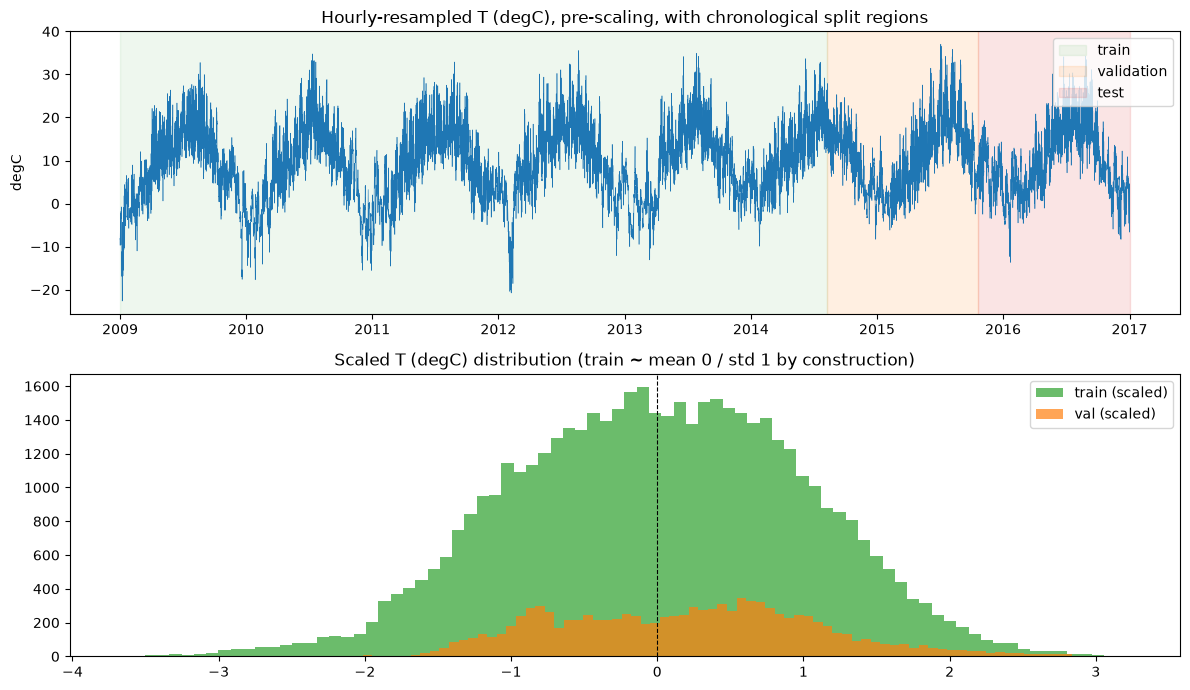

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(hourly_df[pp.TIMESTAMP_COLUMN], hourly_df[pp.TARGET_COLUMN], linewidth=0.4, color="tab:blue")
axes[0].axvspan(train_start, train_end, color="tab:green", alpha=0.08, label="train")
axes[0].axvspan(val_start, val_end, color="tab:orange", alpha=0.12, label="validation")
axes[0].axvspan(test_start, test_end, color="tab:red", alpha=0.12, label="test")
axes[0].set_title("Hourly-resampled T (degC), pre-scaling, with chronological split regions")
axes[0].set_ylabel("degC")
axes[0].legend(loc="upper right")

axes[1].hist(train_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:green", alpha=0.7, label="train (scaled)")
axes[1].hist(val_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:orange", alpha=0.7, label="val (scaled)")
axes[1].set_title("Scaled T (degC) distribution (train ~ mean 0 / std 1 by construction)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend()

fig.tight_layout()
plt.show()

## 9. Mẫu đặc trưng đã xử lý

In [20]:
train_df[[pp.TIMESTAMP_COLUMN] + pp.FEATURE_COLUMNS[:8]].head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar)
0,2009-01-01 00:00:00,0.948907,-2.014297,-2.074466,-1.968587,1.083659,-1.314739,-1.497932,-0.790657
1,2009-01-01 01:00:00,0.948545,-1.986651,-2.046505,-1.931547,1.092974,-1.306490,-1.482811,-0.790727
2,2009-01-01 02:00:00,0.975079,-2.067430,-2.128743,-2.038843,1.068674,-1.329717,-1.525958,-0.790727
3,2009-01-01 03:00:00,1.004227,-2.082853,-2.146338,-2.064173,1.048423,-1.334058,-1.535854,-0.788987
4,2009-01-01 04:00:00,1.024931,-2.135099,-2.199698,-2.144227,0.998809,-1.348385,-1.565146,-0.784464
5,2009-01-01 05:00:00,1.067346,-2.177706,-2.245215,-2.196561,0.998809,-1.359673,-1.584147,-0.786204
6,2009-01-01 06:00:00,1.121018,-2.129315,-2.201036,-2.134908,1.004884,-1.346432,-1.562375,-0.785856
7,2009-01-01 07:00:00,1.209063,-2.041981,-2.120519,-2.017097,1.039310,-1.322553,-1.516853,-0.786899
8,2009-01-01 08:00:00,1.292486,-1.970649,-2.055876,-1.937760,1.012985,-1.302148,-1.485582,-0.780984
9,2009-01-01 09:00:00,1.351786,-1.909535,-1.999648,-1.879213,0.962358,-1.283697,-1.461435,-0.772634


In [21]:
train_df[[pp.TIMESTAMP_COLUMN] + [c for c in pp.FEATURE_COLUMNS if c.startswith("missing_")][:6]].head(3)

,Date Time,missing_p_mbar,missing_T_degC,missing_Tpot_K,missing_Tdew_degC,missing_rh_pct,missing_VPmax_mbar
0,2009-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0


## 9b. Metadata: Thông tin Scaler & Feature Schema

Mọi thứ mà một bên tiêu thụ phía sau cần để *sử dụng* bộ dữ liệu đã xử lý
một cách đúng đắn mà không cần suy ra lại: những đặc trưng nào tồn tại, theo thứ tự nào, và
chính xác mỗi đặc trưng đã được chuẩn hóa như thế nào. Cả hai đều lấy trực tiếp từ các file mà
`preprocess()` ghi ra (khối `scaling` trong `split_metadata.json` và `feature_schema.json`),
không được tính lại ở đây.

In [22]:
scaler_info = split_metadata["scaling"]
print(
    f"method={scaler_info['method']}  fit_scope={scaler_info['fit_scope']}  "
    f"n_features={scaler_info['n_features']}  n_samples_seen={scaler_info['n_samples_seen']}"
)
assert scaler_info["n_samples_seen"] == len(train_df)

scaler_info_table = pd.DataFrame(scaler_info["per_feature"]).T
scaler_info_table.index.name = "feature"
display(scaler_info_table.head(10))

with open(OUTPUT_DIR / "feature_schema.json", encoding="utf-8") as f:
    feature_schema = json.load(f)
print(
    f"\nfeature_schema.json: n_features={feature_schema.get('n_features')}, "
    f"target={feature_schema.get('target')}"
)
assert feature_schema["ordered_features"] == pp.FEATURE_COLUMNS
feature_schema_table = pd.DataFrame({"feature": feature_schema["ordered_features"]})
feature_schema_table.index.name = "index"
feature_schema_table

method=standard_scaler  fit_scope=train_only  n_features=32  n_samples_seen=49090


,mean,scale
feature,,
p (mbar),988.660466,8.291157
T (degC),9.109561,8.644982
Tpot (K),283.195955,8.714511
Tdew (degC),4.609847,6.974469
rh (%),75.942473,16.460460
VPmax (mbar),13.354348,7.677837
VPact (mbar),9.364892,4.210399
VPdef (mbar),3.989373,4.790158
sh (g/kg),5.918537,2.672592



feature_schema.json: n_features=32, target={'name': 'T (degC)', 'index': 1, 'dtype': 'float32', 'unit': 'degC'}


,feature
index,
0,p (mbar)
1,T (degC)
2,Tpot (K)
3,Tdew (degC)
4,rh (%)
5,VPmax (mbar)
6,VPact (mbar)
7,VPdef (mbar)
8,sh (g/kg)


**Phát hiện.** `scaler_info['fit_scope'] == "train_only"` và
`n_samples_seen` bằng đúng số hàng train từ §3 - một xác nhận độc lập,
dựa trên file, cho việc fit chỉ trên train đã được chứng minh bằng
chương trình ở §7. `ordered_features` trong `feature_schema.json` chính xác
là `pp.FEATURE_COLUMNS`, nên một bên tiêu thụ phía sau (ví dụ
`WeatherForecastDataset`) có thể tái tạo lại đúng thứ tự đặc trưng và chỉ số
mục tiêu mà không cần import trực tiếp `src/data/preprocessing.py` - chỉ cần
hai file metadata này.

## Tóm tắt

- Dữ liệu thô 10 phút (420.551 hàng, 14 cột số) được làm sạch, resample
  thành một lưới theo giờ đều đặn nghiêm ngặt, được bổ sung các đặc trưng thời gian dạng
  chu kỳ và các chỉ báo thiếu dữ liệu, chia tách theo thời gian 70/15/15, được impute mà không
  vượt qua ranh giới train/val/test, và được chuẩn hóa bằng scaler chỉ fit trên
  train.
- Bộ dữ liệu đã xử lý (32 đặc trưng, mục tiêu `T (degC)` ở chỉ số
  1) khớp với hợp đồng (contract) đã khóa trong
  `artifacts/preprocessing/feature_schema.json` và đã sẵn sàng cho bước
  tiếp theo: xây dựng sliding window 168 giờ đầu vào / 72 giờ đầu ra.
- Mọi vấn đề được nêu trong `01_data_check.ipynb` (timestamp không sắp xếp/trùng lặp,
  sentinel `-9999`, nhịp dữ liệu thô, khoảng trống SHORT/LONG/CRITICAL,
  tính mùa vụ theo ngày/năm, rủi ro rò rỉ scaler) đều có bằng chứng
  Trước/Sau hoặc phạm vi fit tương ứng ở trên - xem bảng tóm tắt ở đầu
  notebook này để biết chính xác phần nào trả lời phát hiện nào.